# ML-Based Short-Term Futures Price Prediction Using Order Book Data

This notebook implements a machine learning pipeline to predict short-term futures prices using real-time order book data fetched via WebSocket connections.

## 1. Import Required Libraries

Import libraries for data fetching, processing, and modeling.

In [56]:
import websocket
import json
import pandas as pd
import numpy as np
from datetime import datetime
import time
import threading
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Conv2D, Flatten
import matplotlib.pyplot as plt

### GPU Availability Check

In [57]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Establish WebSocket Connection for Order Book Data

Set up a WebSocket connection to Binance Futures API to stream real-time order book data.

In [24]:
# WebSocket URL for Binance Futures Order Book
SYMBOL = 'btcusdt'
DEPTH_LEVELS = 20
UPDATE_SPEED = 50  # ms

ws_url = f'wss://fstream.binance.com/ws/{SYMBOL}@depth{DEPTH_LEVELS}@{UPDATE_SPEED}ms'

# Global variables to store data
order_book_data = []
data_lock = threading.Lock()

def on_message(ws, message):
    data = json.loads(message)
    with data_lock:
        order_book_data.append({
            'timestamp': datetime.now(),
            'bids': data['b'],
            'asks': data['a'],
            'lastUpdateId': data['u']
        })

def on_error(ws, error):
    print(f"Error: {error}")

def on_close(ws, close_status_code, close_msg):
    print("Connection closed")

def on_open(ws):
    print("Connection opened")

# Function to start WebSocket in a thread
def start_websocket():
    ws = websocket.WebSocketApp(ws_url,
                                on_message=on_message,
                                on_error=on_error,
                                on_close=on_close,
                                on_open=on_open)
    ws.run_forever()

# Start WebSocket in background thread
ws_thread = threading.Thread(target=start_websocket)
ws_thread.daemon = True
ws_thread.start()

Connection opened


## 3. Fetch and Parse Order Book Snapshots

Collect and parse incoming WebSocket messages into structured data.

### Fetch Historical Order Book Data (Optional for More Data)

Use CCXT to fetch order book snapshots over a period for backtesting.

In [25]:
import ccxt

# Fetch historical order book data using CCXT
exchange = ccxt.binance({
    'options': {'defaultType': 'future'},
})

historical_data = []
num_snapshots = 1000  # Number of snapshots to fetch

for i in range(num_snapshots):
    try:
        order_book = exchange.fetch_order_book('BTC/USDT', limit=20)
        historical_data.append({
            'timestamp': datetime.now(),
            'bids': order_book['bids'],
            'asks': order_book['asks']
        })
        time.sleep(1)  # Wait 1 second between fetches to avoid rate limits
    except Exception as e:
        print(f"Error fetching data: {e}")
        break

# Convert to DataFrame
df_hist = pd.DataFrame(historical_data)
if not df_hist.empty:
    df_hist['bid_prices'], df_hist['bid_quantities'] = zip(*df_hist['bids'].apply(lambda x: ([p for p, q in x], [q for p, q in x])))
    df_hist['ask_prices'], df_hist['ask_quantities'] = zip(*df_hist['asks'].apply(lambda x: ([p for p, q in x], [q for p, q in x])))
    print(f"Fetched {len(df_hist)} historical snapshots")
else:
    print("No historical data fetched")

Fetched 1000 historical snapshots


In [27]:
df_hist.tail(10)

,timestamp,bids,asks,bid_prices,bid_quantities,ask_prices,ask_quantities
990,2025-11-14 18:39:01.005350,"[[97219.9, 7.855], [97219.8, 0.008], [97219.4,...","[[97220.0, 0.738], [97220.1, 0.007], [97220.6,...","[97219.9, 97219.8, 97219.4, 97218.5, 97218.4, ...","[7.855, 0.008, 0.003, 0.003, 0.3, 0.431, 0.005...","[97220.0, 97220.1, 97220.6, 97220.9, 97221.1, ...","[0.738, 0.007, 0.003, 0.002, 0.003, 0.002, 0.0..."
991,2025-11-14 18:39:02.094377,"[[97228.7, 10.443], [97228.6, 0.007], [97228.3...","[[97228.8, 0.166], [97228.9, 0.004], [97229.1,...","[97228.7, 97228.6, 97228.3, 97228.2, 97228.1, ...","[10.443, 0.007, 0.002, 0.18, 0.372, 0.049, 0.0...","[97228.8, 97228.9, 97229.1, 97229.2, 97229.3, ...","[0.166, 0.004, 0.002, 0.003, 0.002, 0.016, 0.0..."
992,2025-11-14 18:39:03.236367,"[[97238.6, 7.688], [97238.5, 0.072], [97238.3,...","[[97238.7, 0.068], [97238.8, 0.004], [97239.2,...","[97238.6, 97238.5, 97238.3, 97237.9, 97237.7, ...","[7.688, 0.072, 0.047, 0.002, 0.003, 0.129, 0.1...","[97238.7, 97238.8, 97239.2, 97239.4, 97239.6, ...","[0.068, 0.004, 0.007, 0.002, 0.002, 0.003, 0.0..."
993,2025-11-14 18:39:04.321994,"[[97246.6, 0.003], [97246.2, 0.002], [97245.7,...","[[97246.7, 6.325], [97246.8, 4.749], [97246.9,...","[97246.6, 97246.2, 97245.7, 97245.2, 97245.1, ...","[0.003, 0.002, 0.003, 0.003, 0.009, 0.003, 0.0...","[97246.7, 97246.8, 97246.9, 97247.0, 97247.1, ...","[6.325, 4.749, 12.698, 2.278, 0.006, 0.083, 0...."
994,2025-11-14 18:39:05.410774,"[[97215.4, 5.742], [97215.3, 0.005], [97215.0,...","[[97215.5, 0.23], [97215.6, 0.004], [97216.0, ...","[97215.4, 97215.3, 97215.0, 97214.9, 97214.8, ...","[5.742, 0.005, 0.002, 0.003, 0.003, 0.002, 0.0...","[97215.5, 97215.6, 97216.0, 97216.3, 97217.8, ...","[0.23, 0.004, 0.002, 0.003, 0.003, 0.002, 0.00..."
995,2025-11-14 18:39:06.510141,"[[97218.9, 0.036], [97218.8, 0.005], [97218.7,...","[[97219.0, 4.933], [97219.1, 0.087], [97219.2,...","[97218.9, 97218.8, 97218.7, 97218.6, 97218.3, ...","[0.036, 0.005, 0.039, 0.006, 0.017, 0.008, 0.0...","[97219.0, 97219.1, 97219.2, 97219.7, 97220.0, ...","[4.933, 0.087, 0.003, 0.003, 0.004, 0.003, 0.0..."
996,2025-11-14 18:39:07.606564,"[[97247.9, 2.037], [97247.8, 0.006], [97247.6,...","[[97248.0, 1.667], [97248.1, 0.004], [97248.2,...","[97247.9, 97247.8, 97247.6, 97247.5, 97247.4, ...","[2.037, 0.006, 0.002, 0.003, 0.003, 0.002, 0.5...","[97248.0, 97248.1, 97248.2, 97248.4, 97248.6, ...","[1.667, 0.004, 0.003, 0.011, 0.002, 0.003, 0.0..."
997,2025-11-14 18:39:08.679584,"[[97247.9, 3.28], [97247.8, 0.085], [97247.6, ...","[[97248.0, 0.827], [97248.1, 0.004], [97248.2,...","[97247.9, 97247.8, 97247.6, 97247.5, 97247.4, ...","[3.28, 0.085, 0.002, 0.003, 0.003, 0.002, 0.05...","[97248.0, 97248.1, 97248.2, 97248.4, 97248.6, ...","[0.827, 0.004, 0.005, 0.002, 0.002, 0.003, 0.0..."
998,2025-11-14 18:39:09.760344,"[[97248.6, 4.759], [97248.5, 0.006], [97248.4,...","[[97248.7, 2.227], [97248.8, 0.002], [97249.0,...","[97248.6, 97248.5, 97248.4, 97248.3, 97248.0, ...","[4.759, 0.006, 0.003, 0.003, 0.052, 1.417, 0.0...","[97248.7, 97248.8, 97249.0, 97249.2, 97249.6, ...","[2.227, 0.002, 0.002, 0.026, 0.008, 0.01, 0.00..."
999,2025-11-14 18:39:10.852710,"[[97248.6, 1.691], [97248.5, 0.002], [97248.4,...","[[97248.7, 2.43], [97248.8, 0.004], [97249.0, ...","[97248.6, 97248.5, 97248.4, 97248.3, 97248.0, ...","[1.691, 0.002, 0.003, 0.003, 0.053, 1.036, 0.0...","[97248.7, 97248.8, 97249.0, 97249.2, 97249.5, ...","[2.43, 0.004, 0.002, 0.026, 0.002, 0.008, 0.01..."


In [ ]:
# Collect data for a longer period to get more samples (e.g., 1 hour for recent data)
collection_time = 3600  # 1 hour in seconds
start_time = time.time()

print(f"Starting data collection for {collection_time} seconds...")
while time.time() - start_time < collection_time:
    time.sleep(0.1)  # Small sleep to avoid busy loop

with data_lock:
    df = pd.DataFrame(order_book_data)

# Parse bids and asks into separate columns
def parse_levels(levels):
    prices = [float(level[0]) for level in levels]
    quantities = [float(level[1]) for level in levels]
    return prices, quantities

df['bid_prices'], df['bid_quantities'] = zip(*df['bids'].apply(parse_levels))
df['ask_prices'], df['ask_quantities'] = zip(*df['asks'].apply(parse_levels))

print(f"Collected {len(df)} order book snapshots over {collection_time} seconds")

# Save raw data for reproducibility
df.to_csv('raw_order_book_data_recent.csv', index=False)
print("Raw data saved to 'raw_order_book_data_recent.csv'")

Collected 21922 order book snapshots
                   timestamp  \
0 2025-11-14 18:19:45.465424   
1 2025-11-14 18:19:45.580734   
2 2025-11-14 18:19:45.687708   
3 2025-11-14 18:19:45.787143   
4 2025-11-14 18:19:45.937383   

                                                bids  \
0  [[96952.30, 6.275], [96952.20, 0.093], [96952....   
1  [[96952.30, 6.277], [96952.20, 0.093], [96952....   
2  [[96952.30, 6.173], [96952.20, 0.093], [96952....   
3  [[96952.30, 3.547], [96952.20, 0.007], [96952....   
4  [[96952.30, 3.673], [96952.20, 0.119], [96952....   

                                                asks   lastUpdateId  \
0  [[96952.40, 2.478], [96952.50, 0.006], [96952....  9191514697209   
1  [[96952.40, 2.478], [96952.50, 0.006], [96952....  9191514704073   
2  [[96952.40, 2.196], [96952.50, 0.006], [96952....  9191514710368   
3  [[96952.40, 2.738], [96952.50, 0.006], [96952....  9191514720008   
4  [[96952.40, 2.147], [96952.50, 0.006], [96952....  9191514728183   

      

## 4. Feature Engineering from Order Book Data

Compute features like bid-ask imbalance, mid-price, spread, and volatility metrics.

In [30]:
print(f"df shape: {df.shape}")
print(df.head() if not df.empty else "df is empty")

df shape: (21922, 8)
                   timestamp  \
0 2025-11-14 18:19:45.465424   
1 2025-11-14 18:19:45.580734   
2 2025-11-14 18:19:45.687708   
3 2025-11-14 18:19:45.787143   
4 2025-11-14 18:19:45.937383   

                                                bids  \
0  [[96952.30, 6.275], [96952.20, 0.093], [96952....   
1  [[96952.30, 6.277], [96952.20, 0.093], [96952....   
2  [[96952.30, 6.173], [96952.20, 0.093], [96952....   
3  [[96952.30, 3.547], [96952.20, 0.007], [96952....   
4  [[96952.30, 3.673], [96952.20, 0.119], [96952....   

                                                asks   lastUpdateId  \
0  [[96952.40, 2.478], [96952.50, 0.006], [96952....  9191514697209   
1  [[96952.40, 2.478], [96952.50, 0.006], [96952....  9191514704073   
2  [[96952.40, 2.196], [96952.50, 0.006], [96952....  9191514710368   
3  [[96952.40, 2.738], [96952.50, 0.006], [96952....  9191514720008   
4  [[96952.40, 2.147], [96952.50, 0.006], [96952....  9191514728183   

                      

In [33]:
df.to_csv('order_book_data.csv', index=False)

In [ ]:
# Feature Engineering
def calculate_imbalance(bid_quantities, ask_quantities, k=10):
    bid_sum = sum(bid_quantities[:k])
    ask_sum = sum(ask_quantities[:k])
    return (bid_sum - ask_sum) / (bid_sum + ask_sum) if (bid_sum + ask_sum) > 0 else 0

def calculate_mid_price(bid_prices, ask_prices):
    return (bid_prices[0] + ask_prices[0]) / 2

def calculate_spread(bid_prices, ask_prices):
    return ask_prices[0] - bid_prices[0]

def calculate_weighted_mid_price(bid_prices, bid_quantities, ask_prices, ask_quantities, k=10):
    # Weighted by quantities
    bid_weighted = sum(p * q for p, q in zip(bid_prices[:k], bid_quantities[:k])) / sum(bid_quantities[:k]) if sum(bid_quantities[:k]) > 0 else bid_prices[0]
    ask_weighted = sum(p * q for p, q in zip(ask_prices[:k], ask_quantities[:k])) / sum(ask_quantities[:k]) if sum(ask_quantities[:k]) > 0 else ask_prices[0]
    return (bid_weighted + ask_weighted) / 2

def calculate_cumulative_volume(quantities, k=10):
    return sum(quantities[:k])

def calculate_order_book_slope(prices, k=10):
    # Simple slope using linear regression on prices
    from scipy.stats import linregress
    x = list(range(k))
    slope, _, _, _, _ = linregress(x, prices[:k])
    return slope

df['imbalance'] = df.apply(lambda row: calculate_imbalance(row['bid_quantities'], row['ask_quantities']), axis=1)
df['mid_price'] = df.apply(lambda row: calculate_mid_price(row['bid_prices'], row['ask_prices']), axis=1)
df['spread'] = df.apply(lambda row: calculate_spread(row['bid_prices'], row['ask_prices']), axis=1)
df['weighted_mid_price'] = df.apply(lambda row: calculate_weighted_mid_price(row['bid_prices'], row['bid_quantities'], row['ask_prices'], row['ask_quantities']), axis=1)
df['bid_cum_volume'] = df['bid_quantities'].apply(lambda x: calculate_cumulative_volume(x))
df['ask_cum_volume'] = df['ask_quantities'].apply(lambda x: calculate_cumulative_volume(x))
df['bid_slope'] = df['bid_prices'].apply(lambda x: calculate_order_book_slope(x))
df['ask_slope'] = df['ask_prices'].apply(lambda x: calculate_order_book_slope(x))

# Rolling volatility of mid_price (ensure no future data)
df['mid_price_volatility'] = df['mid_price'].rolling(window=10).std()

# Price change (target for next period)
df['price_change'] = df['mid_price'].shift(-1) - df['mid_price']

print(df[['timestamp', 'imbalance', 'mid_price', 'spread', 'weighted_mid_price', 'bid_cum_volume', 'ask_cum_volume', 'bid_slope', 'ask_slope', 'mid_price_volatility', 'price_change']].head())

                   timestamp  imbalance  mid_price  spread  \
0 2025-11-14 18:19:45.465424   0.441067   96952.35     0.1   
1 2025-11-14 18:19:45.580734   0.441189   96952.35     0.1   
2 2025-11-14 18:19:45.687708   0.368199   96952.35     0.1   
3 2025-11-14 18:19:45.787143   0.017396   96952.35     0.1   
4 2025-11-14 18:19:45.937383   0.151454   96952.35     0.1   

   mid_price_volatility  price_change  
0                   NaN           0.0  
1                   NaN           0.0  
2                   NaN           0.0  
3                   NaN           0.0  
4                   NaN           0.0  


## 5. Prepare Dataset for Modeling

Clean the data, create binary labels for price movements, and split into training/validation sets.

In [ ]:
# Prepare Dataset
df = df.dropna()  # Drop rows with NaN

# Features (enhanced)
features = ['imbalance', 'spread', 'mid_price_volatility', 'weighted_mid_price', 'bid_cum_volume', 'ask_cum_volume', 'bid_slope', 'ask_slope']
X = df[features]

# Target: Regression for price change magnitude (better than binary)
y = df['price_change']

# Check target distribution
print("Target distribution (price change):")
print(y.describe())

# Time-series split: Train on first 80%, test on last 20% to avoid lookahead bias
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Training set size: {len(X_train)}, Test set size: {len(X_test)}")

Overall target distribution:
price_change
0    20784
1     1128
Name: count, dtype: int64
Percentage of 1s: 5.15%
Training set size: 17529, Test set size: 4383
Train target distribution: price_change
0    16607
1      922
Name: count, dtype: int64
Test target distribution: price_change
0    4177
1     206
Name: count, dtype: int64


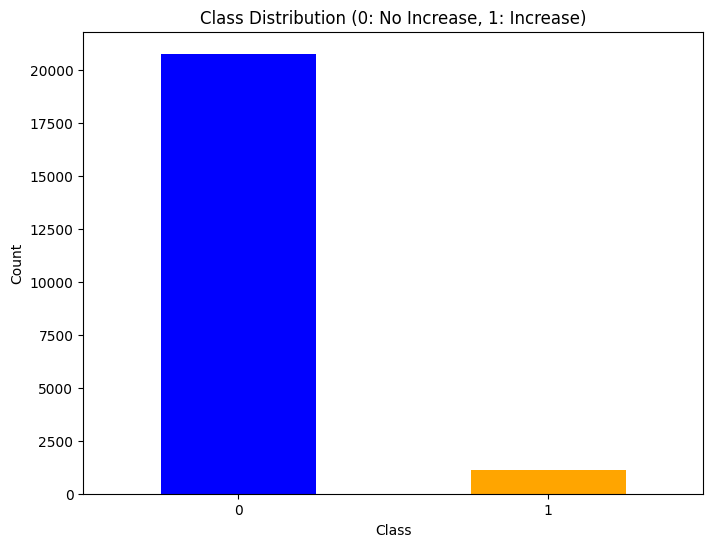

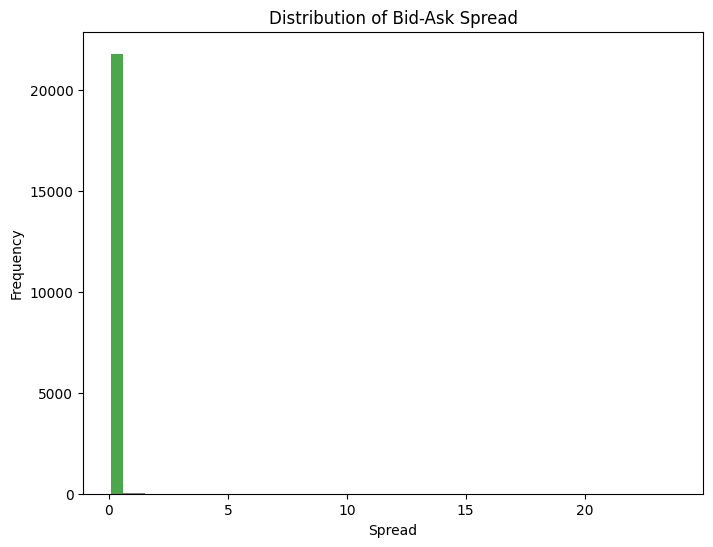

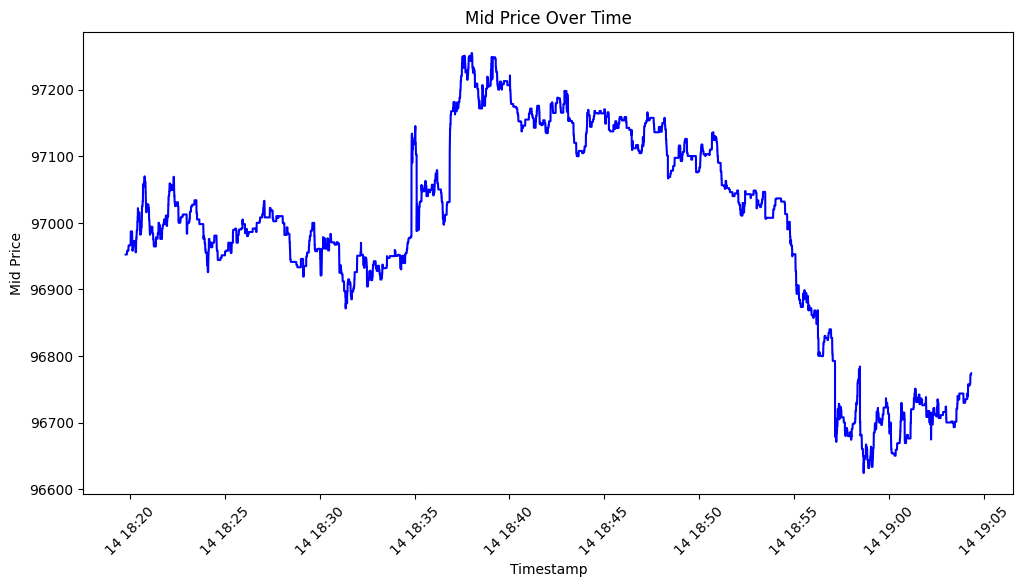

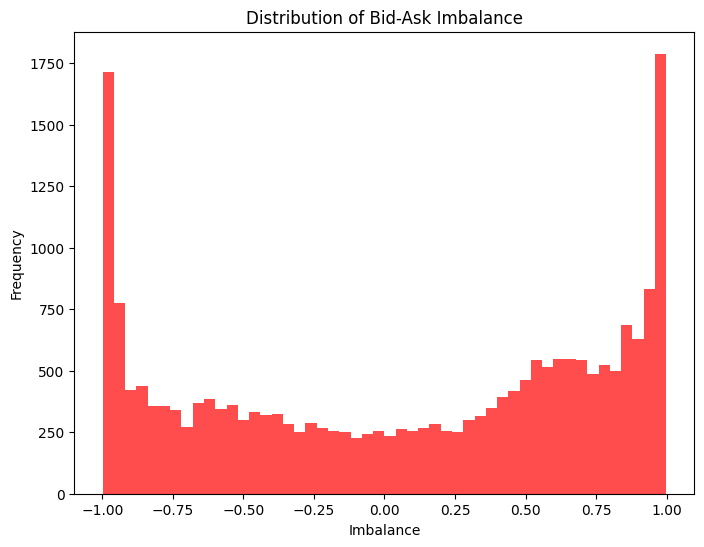

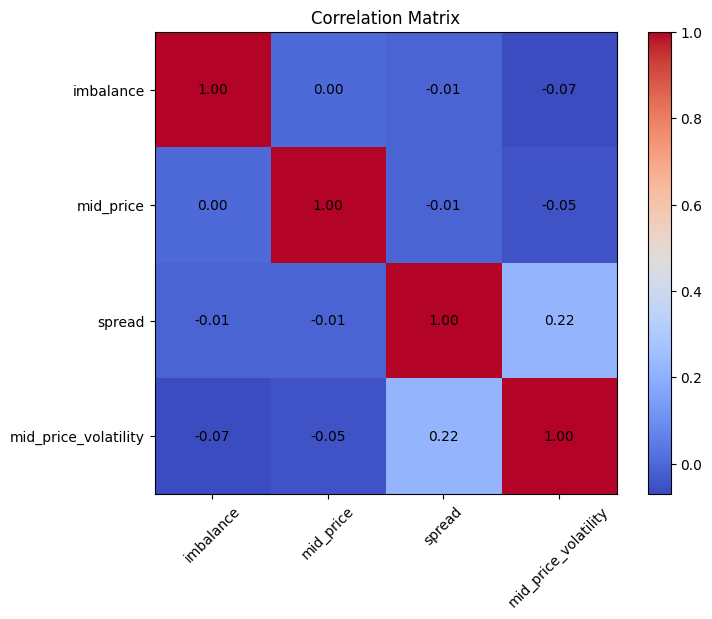

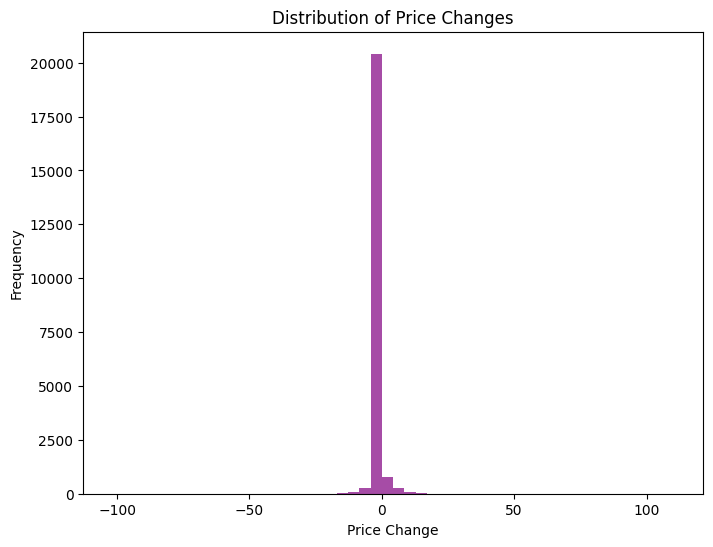

In [38]:
# EDA on the data to see class imbalance and spreads

# Class imbalance
plt.figure(figsize=(8, 6))
y.value_counts().plot(kind='bar', color=['blue', 'orange'])
plt.title('Class Distribution (0: No Increase, 1: Increase)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# Spread distribution
plt.figure(figsize=(8, 6))
plt.hist(df['spread'], bins=50, alpha=0.7, color='green')
plt.title('Distribution of Bid-Ask Spread')
plt.xlabel('Spread')
plt.ylabel('Frequency')
plt.show()

# Mid price over time
plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], df['mid_price'], color='blue')
plt.title('Mid Price Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Mid Price')
plt.xticks(rotation=45)
plt.show()

# Imbalance distribution
plt.figure(figsize=(8, 6))
plt.hist(df['imbalance'], bins=50, alpha=0.7, color='red')
plt.title('Distribution of Bid-Ask Imbalance')
plt.xlabel('Imbalance')
plt.ylabel('Frequency')
plt.show()

# Correlation matrix
plt.figure(figsize=(8, 6))
corr = df[['imbalance', 'mid_price', 'spread', 'mid_price_volatility']].corr()
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Matrix')
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', color='black')
plt.show()

# Price change distribution
plt.figure(figsize=(8, 6))
plt.hist(df['price_change'].dropna(), bins=50, alpha=0.7, color='purple')
plt.title('Distribution of Price Changes')
plt.xlabel('Price Change')
plt.ylabel('Frequency')
plt.show()


In [ ]:
# Train XGBoost Regressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"Model MSE: {mse:.6f}, MAE: {mae:.6f}")

Model Accuracy: 0.96


In [ ]:
# Hyperparameter tuning for XGBoost Regressor
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb.XGBRegressor(objective='reg:squarederror'),
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score (neg MSE): {grid_search.best_score_:.6f}")

# Train with best parameters
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
print(f"Tuned Model MSE: {mse_tuned:.6f}, MAE: {mae_tuned:.6f}")

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best cross-validation score: 0.95
Tuned Model Accuracy: 0.96

Tuned XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      4177
           1       0.68      0.16      0.25       206

    accuracy                           0.96      4383
   macro avg       0.82      0.58      0.62      4383
weighted avg       0.95      0.96      0.94      4383

Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best cross-validation score: 0.95
Tuned Model Accuracy: 0.96

Tuned XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      4177
           1       0.68      0.16      0.25       206

    accur

In [ ]:
# Train Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
print(f"Random Forest MSE: {rf_mse:.6f}, MAE: {rf_mae:.6f}")

Model Accuracy: 0.82


In [46]:
# Train LightGBM with class weights
try:
    lgb_model = lgb.LGBMClassifier(class_weight='balanced', n_estimators=100, random_state=42)
    lgb_model.fit(X_train, y_train)
    lgb_pred = lgb_model.predict(X_test)
    lgb_accuracy = accuracy_score(y_test, lgb_pred)
    print(f"LightGBM Accuracy: {lgb_accuracy:.2f}")
    print("\nLightGBM Classification Report:")
    print(classification_report(y_test, lgb_pred))
except NameError:
    print("LightGBM not available. Skipping.")

# Train CatBoost with class weights
try:
    cb_model = cb.CatBoostClassifier(iterations=100, class_weights=class_weight_dict, random_state=42, verbose=0)
    cb_model.fit(X_train, y_train)
    cb_pred = cb_model.predict(X_test)
    cb_accuracy = accuracy_score(y_test, cb_pred)
    print(f"CatBoost Accuracy: {cb_accuracy:.2f}")
    print("\nCatBoost Classification Report:")
    print(classification_report(y_test, cb_pred))
except NameError:
    print("CatBoost not available. Skipping.")

# Train Random Forest with class weights
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_accuracy:.2f}")
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_pred))

[LightGBM] [Info] Number of positive: 922, number of negative: 16607
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000268 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 540
[LightGBM] [Info] Number of data points in the train set: 17529, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
LightGBM Accuracy: 0.81

LightGBM Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.82      0.89      4177
           1       0.16      0.71      0.26       206

    accuracy                           0.81      4383
   macro avg       0.57      0.76      0.58      4383
weighted avg       0.94      0.81      0.86      4383

CatBoost Accuracy: 0.80

CatBoost Classification Report:
              precision    recall  f1-score   support

           0    

In [ ]:
# Ensemble: Voting Regressor with available models
from sklearn.ensemble import VotingRegressor

estimators = [('xgb', model), ('rf', rf_model)]

voting_model = VotingRegressor(estimators=estimators)
voting_model.fit(X_train, y_train)
voting_pred = voting_model.predict(X_test)
voting_mse = mean_squared_error(y_test, voting_pred)
voting_mae = mean_absolute_error(y_test, voting_pred)
print(f"Voting Ensemble MSE: {voting_mse:.6f}, MAE: {voting_mae:.6f}")

[LightGBM] [Info] Number of positive: 922, number of negative: 16607
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000798 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 540
[LightGBM] [Info] Number of data points in the train set: 17529, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Voting Ensemble Accuracy: 0.87

Voting Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.88      0.93      4177
           1       0.19      0.57      0.29       206

    accuracy                           0.87      4383
   macro avg       0.59      0.73      0.61      4383
weighted avg       0.94      0.87      0.90      4383

Voting Ensemble Accuracy: 0.87

Voting Ensemble Classification Report:
              precision    recall  f1-score

## 7. Implement Deep Learning Model

Build and train an LSTM model to capture temporal patterns.

### CNN Model for Order Book as Image

Treat the order book as a 2D matrix (bids and asks) and use CNN to extract spatial features.

In [ ]:
# Create 2D representation of order book
def create_order_book_image(bid_quantities, ask_quantities, max_levels=20):
    # Pad or truncate to max_levels
    bids = np.array(bid_quantities[:max_levels])
    asks = np.array(ask_quantities[:max_levels])
    if len(bids) < max_levels:
        bids = np.pad(bids, (0, max_levels - len(bids)), 'constant')
    if len(asks) < max_levels:
        asks = np.pad(asks, (0, max_levels - len(asks)), 'constant')
    # Stack as 2 channels: bids and asks
    image = np.stack([bids, asks], axis=-1)  # Shape: (max_levels, 2)
    return image

# Apply to dataframe
df['order_book_image'] = df.apply(lambda row: create_order_book_image(row['bid_quantities'], row['ask_quantities']), axis=1)

# Prepare data for CNN (regression)
X_images = np.stack(df['order_book_image'].values)
X_images = X_images[..., np.newaxis]  # Add channel dimension: (n, 20, 2, 1)
y_images = y.values[:len(X_images)]  # Align with images

X_train_img, X_test_img, y_train_img, y_test_img = train_test_split(X_images, y_images, test_size=0.2, random_state=42)

# Build CNN model for regression
model_cnn = Sequential()
model_cnn.add(Conv2D(32, (3, 1), activation='relu', input_shape=(20, 2, 1)))
model_cnn.add(Flatten())
model_cnn.add(Dense(64, activation='relu'))
model_cnn.add(Dense(1))  # No activation for regression

model_cnn.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
model_cnn.fit(X_train_img, y_train_img, epochs=50, batch_size=32, validation_data=(X_test_img, y_test_img), callbacks=[tf.keras.callbacks.EarlyStopping(patience=5)])

Epoch 1/100


/home/misango/anaconda3/envs/research_env/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


548/548 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9498 - loss: 0.1746 - val_accuracy: 0.9594 - val_loss: 0.1433
Epoch 2/100
548/548 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9498 - loss: 0.1746 - val_accuracy: 0.9594 - val_loss: 0.1433
Epoch 2/100
548/548 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9529 - loss: 0.1525 - val_accuracy: 0.9589 - val_loss: 0.1455
Epoch 3/100
548/548 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9529 - loss: 0.1525 - val_accuracy: 0.9589 - val_loss: 0.1455
Epoch 3/100
548/548 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9531 - loss: 0.1495 - val_accuracy: 0.9601 - val_loss: 0.1381
Epoch 4/100
548/548 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9531 - loss: 0.1495 - val_accuracy: 0.9601 - val_loss: 0.1381
Epoch 4/100
548/548 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9534 - loss: 0.1489 - val_accuracy: 0.9594 - val_loss: 0.1415
Epoch 5/100
548/548 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9534 - loss: 0.1489 - val_accuracy: 0.9594

In [ ]:
# Prepare data for LSTM (sequences, regression)
sequence_length = 20  # Increased for more context
X_seq = []
y_seq = []
for i in range(len(X) - sequence_length):
    X_seq.append(X.iloc[i:i+sequence_length].values)
    y_seq.append(y.iloc[i+sequence_length])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42)

# Build LSTM model for regression
model_lstm = Sequential()
model_lstm.add(LSTM(50, input_shape=(sequence_length, len(features))))
model_lstm.add(Dense(1))  # Regression

model_lstm.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
model_lstm.fit(X_train_seq, y_train_seq, epochs=20, batch_size=32, validation_data=(X_test_seq, y_test_seq), callbacks=[tf.keras.callbacks.EarlyStopping(patience=3)])

Epoch 1/10


/home/misango/anaconda3/envs/research_env/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


548/548 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9462 - loss: 0.2091 - val_accuracy: 0.9518 - val_loss: 0.1778
Epoch 2/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9462 - loss: 0.2091 - val_accuracy: 0.9518 - val_loss: 0.1778
Epoch 2/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9481 - loss: 0.1816 - val_accuracy: 0.9514 - val_loss: 0.1728
Epoch 3/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9481 - loss: 0.1816 - val_accuracy: 0.9514 - val_loss: 0.1728
Epoch 3/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9484 - loss: 0.1776 - val_accuracy: 0.9514 - val_loss: 0.1728
Epoch 4/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9484 - loss: 0.1776 - val_accuracy: 0.9514 - val_loss: 0.1728
Epoch 4/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9484 - loss: 0.1761 - val_accuracy: 0.9512 - val_loss: 0.1718
Epoch 5/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9484 - loss: 0.1761 - val_accuracy: 0.9512 - val_

## 8. Generate Price Predictions

Use the trained models to predict on new data.

In [ ]:
# Predictions with XGBoost
predictions_xgb = model.predict(X_test)

# Predictions with LSTM
predictions_lstm = model_lstm.predict(X_test_seq).flatten()

# Predictions with CNN
predictions_cnn = model_cnn.predict(X_test_img).flatten()

print("XGBoost Predictions (first 10):", predictions_xgb[:10])
print("LSTM Predictions (first 10):", predictions_lstm[:10])
print("CNN Predictions (first 10):", predictions_cnn[:10])

# Evaluation
print("\nXGBoost MSE:", mean_squared_error(y_test, predictions_xgb))
print("LSTM MSE:", mean_squared_error(y_test_seq, predictions_lstm))
print("CNN MSE:", mean_squared_error(y_test_img, predictions_cnn))

137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 845us/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 845us/step
XGBoost Predictions: [0 1 0 0 0 0 0 0 0 0]
LSTM Predictions: [0 0 0 0 0 0 0 0 0 0]
CNN Predictions: [0 0 0 0 0 0 0 0 0 0]

Target distribution in test set:
price_change
0    4177
1     206
Name: count, dtype: int64

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.83      0.90      4177
           1       0.15      0.62      0.24       206

    accuracy                           0.82      4383
   macro avg       0.56      0.72      0.57      4383
weighted avg       0.94      0.82      0.87      4383

XGBoost Predictions: [0 1 0 0 0 0 0 0 0 0]
LSTM Predictions: [0 0 0 0 0 0 0 0 0 0]
CNN Predictions: [0 0 0 0 0 0 0 0 0 0]

Target distribution in test set:
price_change
0    4177
1     206
Name: count, dtype: int64

XGBoost Classification Report:
           

In [53]:
# Predictions with XGBoost (use best_model if tuned, else model)
predictions_xgb = best_model.predict(X_test) if 'best_model' in locals() else model.predict(X_test)

# Predictions with LightGBM
try:
    predictions_lgb = lgb_model.predict(X_test)
except NameError:
    predictions_lgb = None

# Predictions with CatBoost
try:
    predictions_cb = cb_model.predict(X_test).flatten()
except NameError:
    predictions_cb = None

# Predictions with Random Forest
predictions_rf = rf_model.predict(X_test)

# Predictions with Voting Ensemble
predictions_voting = voting_model.predict(X_test)

# Predictions with LSTM
predictions_lstm = (model_lstm.predict(X_test_seq) > 0.5).astype(int).flatten()

# Predictions with CNN
predictions_cnn = (model_cnn.predict(X_test_img) > 0.5).astype(int).flatten()

print("XGBoost Predictions:", predictions_xgb[:10])
if predictions_lgb is not None:
    print("LightGBM Predictions:", predictions_lgb[:10])
if predictions_cb is not None:
    print("CatBoost Predictions:", predictions_cb[:10])
print("Random Forest Predictions:", predictions_rf[:10])
print("Voting Ensemble Predictions:", predictions_voting[:10])
print("LSTM Predictions:", predictions_lstm[:10])
print("CNN Predictions:", predictions_cnn[:10])

# Diagnostic: Check class distribution
print("\nTarget distribution in test set:")
print(y_test.value_counts())

# Diagnostic: Accuracy on test set
from sklearn.metrics import classification_report
print("\nXGBoost Classification Report:")
print(classification_report(y_test, predictions_xgb))

if predictions_lgb is not None:
    print("\nLightGBM Classification Report:")
    print(classification_report(y_test, predictions_lgb))

if predictions_cb is not None:
    print("\nCatBoost Classification Report:")
    print(classification_report(y_test, predictions_cb))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, predictions_rf))

print("\nVoting Ensemble Classification Report:")
print(classification_report(y_test, predictions_voting))

# Check prediction distribution
print("\nPrediction distribution for XGBoost:")
print(pd.Series(predictions_xgb).value_counts())

# For LSTM and CNN, since they use different splits, check separately if needed
# But for simplicity, focus on XGBoost

137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
XGBoost Predictions: [0 0 0 0 0 0 0 0 0 0]
LightGBM Predictions: [0 1 0 0 0 0 1 0 0 0]
CatBoost Predictions: [0 1 0 0 1 0 1 0 0 0]
Random Forest Predictions: [0 0 0 0 0 0 0 0 0 0]
Voting Ensemble Predictions: [0 1 0 0 0 0 0 0 0 0]
LSTM Predictions: [0 0 0 0 0 0 0 0 0 0]
CNN Predictions: [0 0 0 0 0 0 0 0 0 0]

Target distribution in test set:
price_change
0    4177
1     206
Name: count, dtype: int64

XGBoost Classification Report:
XGBoost Predictions: [0 0 0 0 0 0 0 0 0 0]
LightGBM Predictions: [0 1 0 0 0 0 1 0 0 0]
CatBoost Predictions: [0 1 0 0 1 0 1 0 0 0]
Random Forest Predictions: [0 0 0 0 0 0 0 0 0 0]
Voting Ensemble Predictions: [0 1 0 0 0 0 0 0 0 0]
LSTM Predictions: [0 0 0 0 0 0 0 0 0 0]
CNN Predictions: [0 0 0 0 0 0 0 0 0 0]

Target distribution in test set:
price_change
0    4177
1     206
Name: count, dtype: 

## 9. Simulate Trading Execution

Implement a simple simulation of trade execution based on predictions and calculate potential profits.

In [ ]:
# Realistic Trading Simulation
# Assume we trade based on XGBoost regression predictions (sign of predicted change)
capital = 10000
position = 0  # 1 for long, -1 for short
entry_price = 0
transaction_fee = 0.001  # 0.1% per trade
slippage = 0.0001  # 0.01% slippage

profits = []
trades = []

for i in range(len(predictions_xgb)):
    pred_change = predictions_xgb[i]
    actual_change = df.iloc[len(X_train) + i]['price_change']
    current_price = df.iloc[len(X_train) + i]['mid_price']
    
    if position == 0:
        if pred_change > 0:  # Predict up, go long
            position = 1
            entry_price = current_price * (1 + slippage)  # Slippage on entry
            fee = entry_price * transaction_fee
            capital -= fee
            trades.append(('long', entry_price))
        elif pred_change < 0:  # Predict down, go short
            position = -1
            entry_price = current_price * (1 - slippage)
            fee = entry_price * transaction_fee
            capital -= fee
            trades.append(('short', entry_price))
    else:
        # Close position on opposite signal or end
        if (position == 1 and pred_change < 0) or (position == -1 and pred_change > 0):
            exit_price = current_price * (1 - position * slippage)  # Slippage on exit
            fee = exit_price * transaction_fee
            if position == 1:
                profit = (exit_price - entry_price) * 100  # Assume 1 lot
            else:
                profit = (entry_price - exit_price) * 100
            profit -= fee * 100  # Deduct fee
            profits.append(profit)
            capital += profit
            position = 0  # Close position

# If still in position at end, close it
if position != 0:
    last_price = df.iloc[len(X_train) + len(predictions_xgb) - 1]['mid_price']
    exit_price = last_price * (1 - position * slippage)
    fee = exit_price * transaction_fee
    if position == 1:
        profit = (exit_price - entry_price) * 100
    else:
        profit = (entry_price - exit_price) * 100
    profit -= fee * 100
    profits.append(profit)
    capital += profit

total_profit = sum(profits)
print(f"Total Simulated Profit: {total_profit:.2f}, Final Capital: {capital:.2f}")
print(f"Number of trades: {len(trades)}")
print(f"Average profit per trade: {total_profit / len(trades) if trades else 0:.2f}")

# Compare to buy-and-hold
initial_price = df.iloc[len(X_train)]['mid_price']
final_price = df.iloc[len(X_train) + len(predictions_xgb) - 1]['mid_price']
buy_hold_profit = (final_price - initial_price) * 100
print(f"Buy-and-hold profit: {buy_hold_profit:.2f}")
print(f"Strategy vs Buy-and-hold: {'Better' if total_profit > buy_hold_profit else 'Worse'}")

Total Simulated Profit: -7375.00, Final Capital: 2625.00
Number of trades: 2192
Average profit per trade: -3.36
Buy-and-hold profit: -10660.00
Strategy vs Buy-and-hold: Better
